In [1]:
import pandas as pd

# Load the SMS Spam Collection dataset
df = pd.read_csv(r"C:\Users\m.arasteh\data\bitcoin.csv",sep=",")

# Selecting the Required Columns
df = df[
    [
        "Open Time",
        "Close",
        "Volume",
        "Number of trades",
        "Taker buy base asset volume"
    ]
]

df["Open Time"] = pd.to_datetime(
    df["Open Time"],
    unit="ms"
)

df = df.rename(
    columns={
        "Open Time": "Date",
        "Close": "Price"
    }
)

df.set_index("Date", inplace=True)

# Display the first five samples
df.head()

,Price,Volume,Number of trades,Taker buy base asset volume
Date,,,,
2021-01-01 00:00:00,28961.66,27.457032,1292,16.777195
2021-01-01 00:01:00,29009.91,58.477501,1651,33.733818
2021-01-01 00:02:00,28989.30,42.470329,986,13.247444
2021-01-01 00:03:00,28982.69,30.360677,959,9.456028
2021-01-01 00:04:00,28975.65,24.124339,726,6.814644


In [2]:
train_size = int(len(df) * 0.8)

train_data = df.iloc[:train_size]
test_data = df.iloc[train_size:]

print("Total observations:", len(df))
print("Training observations:", len(train_data))
print("Test observations:", len(test_data))

Total observations: 188317
Training observations: 150653
Test observations: 37664


In [3]:
print("Training period:")
print(train_data.index.min())
print(train_data.index.max())

print("\nTest period:")
print(test_data.index.min())
print(test_data.index.max())

Training period:
2021-01-01 00:00:00
2021-04-15 17:41:00

Test period:
2021-04-15 17:42:00
2021-05-12 04:39:00


In [4]:
from sklearn.preprocessing import MinMaxScaler

# Data normalization
# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train_data)

train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

# Converting Normalized Data to DataFrames
train_scaled = pd.DataFrame(
    train_scaled,
    columns=train_data.columns,
    index=train_data.index
)

test_scaled = pd.DataFrame(
    test_scaled,
    columns=test_data.columns,
    index=test_data.index
)

train_scaled.head()

,Price,Volume,Number of trades,Taker buy base asset volume
Date,,,,
2021-01-01 00:00:00,0.019861,0.014707,0.044301,0.014224
2021-01-01 00:01:00,0.021180,0.031323,0.056611,0.028600
2021-01-01 00:02:00,0.020616,0.022749,0.033809,0.011231
2021-01-01 00:03:00,0.020436,0.016262,0.032883,0.008017
2021-01-01 00:04:00,0.020243,0.012922,0.024894,0.005778


In [5]:
print("Min values: \n", train_scaled.min(),"\n")
print("Max values: \n", train_scaled.max())

Min values: 
 Price                          0.0
Volume                         0.0
Number of trades               0.0
Taker buy base asset volume    0.0
dtype: float64 

Max values: 
 Price                          1.0
Volume                         1.0
Number of trades               1.0
Taker buy base asset volume    1.0
dtype: float64


In [6]:
# Selecting the Input Features and Target
features = [
    "Price",
    "Volume",
    "Number of trades",
    "Taker buy base asset volume"
]

target = "Price"

In [7]:
# Creating a Multivariate Sliding-Window Function

import numpy as np

def create_sliding_windows(data, window_size, horizon):
    X = []
    y = []

    # Calculate the number of samples
    num_samples = len(data) - window_size - horizon + 1

    for i in range(num_samples):

        # Input window
        input_window = data[
            i : i + window_size
        ]

        # Target horizon
        target = data[
            i + window_size :
            i + window_size + horizon
        ]

        X.append(input_window)
        y.append(target)

    return np.array(X), np.array(y)

In [8]:
window_size = 5
horizon = 3

X_train, y_train = create_sliding_windows(
    train_scaled,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_scaled,
    window_size=window_size,
    horizon=horizon
)

# Select Price as the target
y_train = y_train[:, :, 0]
y_test = y_test[:, :, 0]

In [9]:
# Example: creating sliding window on test dataset
# Print two top values
for i in range(2):
    print(X_test[i], "---->", y_test[i], "\n")

[[0.93414848 0.02645823 0.05026745 0.0179055 ]
 [0.9341225  0.02073018 0.04707859 0.01847604]
 [0.9369356  0.0140614  0.03528323 0.01194286]
 [0.93762015 0.01754152 0.04409546 0.01562965]
 [0.93747219 0.01894065 0.03888356 0.01656932]] ----> [0.93789637 0.93805363 0.93768961] 

[[0.9341225  0.02073018 0.04707859 0.01847604]
 [0.9369356  0.0140614  0.03528323 0.01194286]
 [0.93762015 0.01754152 0.04409546 0.01562965]
 [0.93747219 0.01894065 0.03888356 0.01656932]
 [0.93789637 0.00965377 0.03398025 0.00872169]] ----> [0.93805363 0.93768961 0.93696596] 



In [10]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (150646, 5, 4)
y_train shape: (150646, 3)
X_test shape: (37657, 5, 4)
y_test shape: (37657, 3)


In [11]:
# Before sending the data to a PyTorch model, we convert them to tensors:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
print("X_train tensor shape:", X_train_tensor.shape)
print("y_train tensor shape:", y_train_tensor.shape)
print("X_test tensor shape:", X_test_tensor.shape)
print("y_test tensor shape:", y_test_tensor.shape)

X_train tensor shape: torch.Size([150646, 5, 4])
y_train tensor shape: torch.Size([150646, 3])
X_test tensor shape: torch.Size([37657, 5, 4])
y_test tensor shape: torch.Size([37657, 3])


In [12]:
from torch.utils.data import TensorDataset, DataLoader

def create_data_loaders(X_train, y_train, X_test, y_test, batch_size=128):
    """
    Create PyTorch DataLoaders for
    training and test datasets.
    """

    # Create TensorDatasets
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    # Create DataLoaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False  # to preserve the chronological order 
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False  # to preserve the chronological order 
    )

    return train_loader, test_loader

In [13]:
train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [14]:
# يheck the first batch:

X_batch, y_batch = next(iter(train_loader))

print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)

Input shape: torch.Size([128, 5, 4])
Target shape: torch.Size([128, 3])


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [16]:
import torch
import torch.nn as nn

class FFNNModel(nn.Module):

    def __init__(
        self,
        window_size=60,
        feature_size=4,
        hidden_size=128,
        horizon=1
    ):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(window_size * feature_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, horizon)
        )

    def forward(self, x):
        # Flatten the time and feature dimensions
        x = x.reshape(x.size(0), -1)
        return self.model(x)

In [17]:
window_size = 60
feature_size = 4
hidden_size = 128
horizon = 3

X_train, y_train = create_sliding_windows(
    train_scaled,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_scaled,
    window_size=window_size,
    horizon=horizon
)

# Select Price as the target
y_train = y_train[:, :, 0]
y_test = y_test[:, :, 0]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [18]:
model_FFNN = FFNNModel(
    window_size=window_size,
    feature_size=feature_size,
    hidden_size=hidden_size,
    horizon=horizon
)

In [19]:
print(model_FFNN)

FFNNModel(
  (model): Sequential(
    (0): Linear(in_features=240, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3, bias=True)
  )
)


In [20]:
# Loss function: MAE
criterion = nn.L1Loss()

# Optimizer: Adam
optimizer = torch.optim.Adam(
    model_FFNN.parameters(),
    lr=0.0001
)

In [21]:
# Train model

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=100):

    # Move model to device
    model = model.to(device)

    # Store training history
    train_losses = []
    test_losses = []


    for epoch in range(epochs):

        # -----------------------
        # Training phase
        # -----------------------
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Clear previous gradients
            optimizer.zero_grad()

            # Forward pass
            predictions = model(inputs)

            # Compute MAE loss
            loss = criterion(predictions, targets)

            # Backpropagation
            loss.backward()

            # Update model parameters
            optimizer.step()

            # Store batch loss
            running_loss += loss.item()


        # Average training loss
        epoch_train_loss = (running_loss / len(train_loader))

        # -----------------------
        # Evaluation phase
        # -----------------------
        model.eval()
        running_test_loss = 0.0

        # Disable gradient calculation
        with torch.no_grad():
            for inputs, targets in test_loader:

                # Move data to device
                inputs = inputs.to(device)
                targets = targets.to(device)

                # Forward pass
                predictions = model(inputs)

                # Compute MAE loss
                loss = criterion(predictions, targets)

                # Store batch loss
                running_test_loss += loss.item()


        # Average test loss
        epoch_test_loss = (running_test_loss / len(test_loader))

        # -----------------------
        # Store history
        # -----------------------
        train_losses.append(epoch_train_loss)
        test_losses.append(epoch_test_loss)

        # Print results
        if(epoch%10==0):
            print(
                f"Epoch [{epoch}/{epochs}] "
                f"Train MAE: {epoch_train_loss:.4f} "
                f"Test MAE: {epoch_test_loss:.4f}"
            )

    return train_losses, test_losses

In [22]:
train_losses_FFNN, test_losses_FFNN = train_model(
    model=model_FFNN,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=21
)

Epoch [0/21] Train MAE: 0.0136 Test MAE: 0.0071
Epoch [10/21] Train MAE: 0.0042 Test MAE: 0.0071
Epoch [20/21] Train MAE: 0.0037 Test MAE: 0.0065


In [23]:
import matplotlib.pyplot as plt
def plot_train_test_loss(
    train_losses,
    test_losses,
    title="Training and Test Loss",
    ylabel="Loss",
    figsize=(10, 5)
):
    """
    Plot training and test loss for each epoch.
    """

    # Create epoch numbers
    epochs = range(1, len(train_losses) + 1)


    # Create figure
    plt.figure(figsize=figsize)


    # Plot training loss
    plt.plot(epochs, train_losses, marker='o', label="Training Loss")

    # Plot test loss
    plt.plot(epochs, test_losses, marker='s', label="Test Loss")


    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

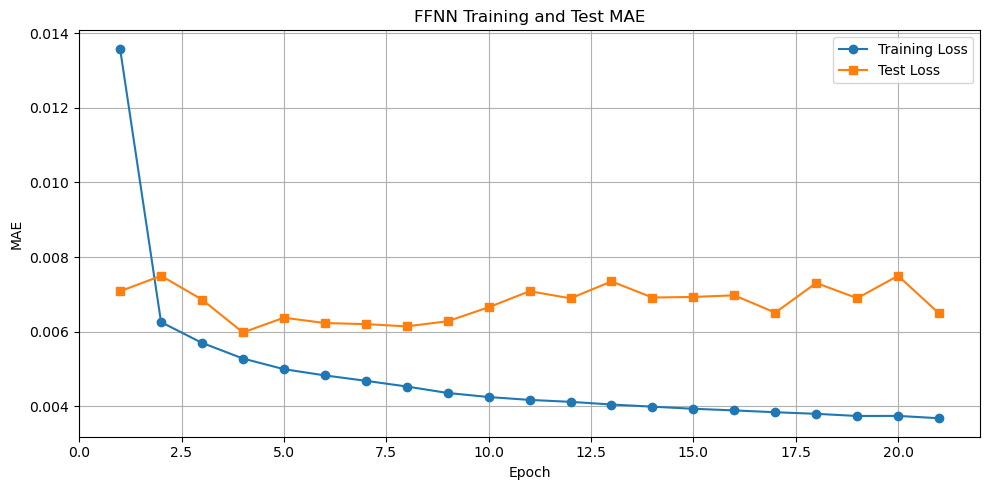

In [24]:
plot_train_test_loss(
    train_losses=train_losses_FFNN,
    test_losses=test_losses_FFNN,
    title="FFNN Training and Test MAE",
    ylabel="MAE"
)

In [25]:
import numpy as np
import torch

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


def evaluate_model(model, test_loader):
    """
    Evaluate a time-series forecasting model using:

    - MAE
    - MSE
    - RMSE
    - MAPE
    - sMAPE
    """

    # Move model to device
    model = model.to(device)

    # Set model to evaluation mode
    model.eval()

    predictions_list = []
    actual_list = []

    # Disable gradient calculation
    with torch.no_grad():

        for inputs, targets in test_loader:

            # Move data to device
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Make predictions
            outputs = model(inputs)

            # Move tensors to CPU
            outputs = outputs.cpu().numpy()
            targets = targets.cpu().numpy()

            # Store predictions and targets
            predictions_list.append(outputs)
            actual_list.append(targets)


    # Combine all batches
    predictions = np.concatenate(
        predictions_list,
        axis=0
    )

    actual_values = np.concatenate(
        actual_list,
        axis=0
    )


    # Flatten arrays for horizon = 1
    predictions = predictions.flatten()
    actual_values = actual_values.flatten()

    # -----------------------------
    # Calculate MAE
    # -----------------------------
    mae = mean_absolute_error(actual_values, predictions)

    # -----------------------------
    # Calculate MSE
    # -----------------------------
    mse = mean_squared_error(actual_values, predictions)

    # -----------------------------
    # Calculate RMSE
    # -----------------------------
    rmse = np.sqrt(mse)

    # -----------------------------
    # Calculate MAPE
    # -----------------------------
    epsilon = 1e-8
    mape = np.mean(np.abs((actual_values - predictions) / (actual_values + epsilon))) * 100

    # -----------------------------
    # Calculate sMAPE
    # -----------------------------
    smape = np.mean(
        2 * np.abs(actual_values - predictions) / (np.abs(actual_values)
            +
            np.abs(predictions)
            +
            epsilon
        )
    ) * 100


    # Store all metrics
    metrics = {

        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "sMAPE (%)": smape
    }


    # Print results
    print("\nModel Evaluation Results")
    print("-" * 30)

    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric}: {value:.4f}")


In [26]:
 evaluate_model(
    model=model_FFNN,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 0.0065
MSE: 0.0001
RMSE: 0.0081
MAPE (%): 0.9134
sMAPE (%): 0.9067


In [27]:
def predict_next_price(model, data, window_size):

    # Move model to device
    model = model.to(device)

    # Set model to evaluation mode
    model.eval()

    # Get the latest window
    input_data = data[-window_size:]


    # Convert input to NumPy array
    input_data = np.asarray(input_data, dtype=np.float32)

    # Convert input to PyTorch tensor
    input_tensor = torch.tensor(input_data, dtype=torch.float32)

    # Add batch dimension
    input_tensor = input_tensor.unsqueeze(0)

    # Move input to device
    input_tensor = input_tensor.to(device)


    # Disable gradient calculation
    with torch.no_grad():
        prediction = model(input_tensor)


    # Convert prediction to NumPy
    prediction = prediction.cpu().numpy()

    # Inverse transform the Price
    price_min = scaler.data_min_[0]
    price_max = scaler.data_max_[0]

    prediction = (
        prediction * (price_max - price_min)
        + price_min
    )

    return prediction

In [28]:
next_price = predict_next_price(
    model=model_FFNN,
    data=test_scaled,
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [57684.51463871 57837.6186002  57880.91269551]


In [29]:
class RNNModel(nn.Module):

    def __init__(
        self,
        feature_size=4,
        hidden_size=128,
        num_layers=1,
        horizon=3
    ):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=feature_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):

        output, _ = self.rnn(x)

        # Select the last time step
        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [30]:
window_size = 60
feature_size = 4
hidden_size = 128
num_layers = 1
horizon = 3

X_train, y_train = create_sliding_windows(
    train_scaled,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_scaled,
    window_size=window_size,
    horizon=horizon
)

# Select Price as the target
y_train = y_train[:, :, 0]
y_test = y_test[:, :, 0]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [31]:
model_RNN = RNNModel(
    feature_size=feature_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    horizon=horizon
)

In [32]:
print(model_RNN)

RNNModel(
  (rnn): RNN(4, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [33]:
# Loss function: MAE
criterion = nn.L1Loss()

# Optimizer: Adam
optimizer = torch.optim.Adam(
    model_RNN.parameters(),
    lr=0.0001
)

In [34]:
train_losses_RNN, test_losses_RNN = train_model(
    model=model_RNN,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 0.0342 Test MAE: 0.1530
Epoch [10/100] Train MAE: 0.0032 Test MAE: 0.0236
Epoch [20/100] Train MAE: 0.0029 Test MAE: 0.0180
Epoch [30/100] Train MAE: 0.0026 Test MAE: 0.0176
Epoch [40/100] Train MAE: 0.0024 Test MAE: 0.0174
Epoch [50/100] Train MAE: 0.0023 Test MAE: 0.0173
Epoch [60/100] Train MAE: 0.0023 Test MAE: 0.0154
Epoch [70/100] Train MAE: 0.0023 Test MAE: 0.0156
Epoch [80/100] Train MAE: 0.0022 Test MAE: 0.0149
Epoch [90/100] Train MAE: 0.0022 Test MAE: 0.0146


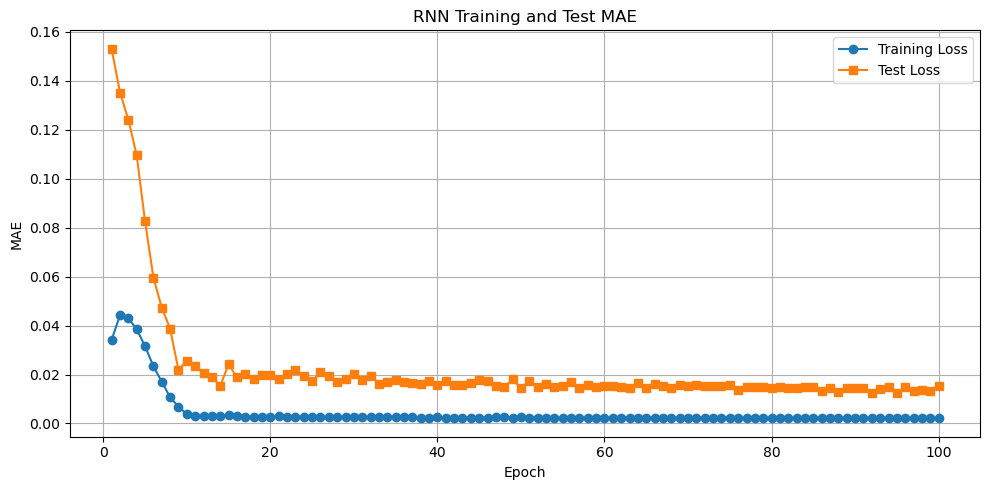

In [35]:
plot_train_test_loss(
    train_losses=train_losses_RNN,
    test_losses=test_losses_RNN,
    title="RNN Training and Test MAE",
    ylabel="MAE"
)

In [36]:
 evaluate_model(
    model=model_RNN,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 0.0153
MSE: 0.0003
RMSE: 0.0162
MAPE (%): 2.1302
sMAPE (%): 2.1035


In [37]:
next_price = predict_next_price(
    model=model_RNN,
    data=test_scaled,
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [57903.76604982 57927.38437908 57939.03335665]


In [38]:
class LSTMModel(nn.Module):

    def __init__(
        self,
        feature_size=4,
        hidden_size=128,
        num_layers=1,
        horizon=1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=feature_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        # Take the last time step
        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [39]:
window_size = 60
feature_size = 4
hidden_size = 128
num_layers = 1
horizon = 3

X_train, y_train = create_sliding_windows(
    train_scaled,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_scaled,
    window_size=window_size,
    horizon=horizon
)

# Select Price as the target
y_train = y_train[:, :, 0]
y_test = y_test[:, :, 0]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [40]:
model_LSTM = LSTMModel(
    feature_size=feature_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    horizon=horizon
)

In [41]:
print(model_LSTM)

LSTMModel(
  (lstm): LSTM(4, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [42]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_LSTM.parameters(),
    lr=0.0001
)

In [43]:
train_losses_LSTM, test_losses_LSTM = train_model(
    model=model_LSTM,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 0.0380 Test MAE: 0.1290
Epoch [10/100] Train MAE: 0.0069 Test MAE: 0.0560
Epoch [20/100] Train MAE: 0.0044 Test MAE: 0.0415
Epoch [30/100] Train MAE: 0.0035 Test MAE: 0.0357
Epoch [40/100] Train MAE: 0.0033 Test MAE: 0.0306
Epoch [50/100] Train MAE: 0.0030 Test MAE: 0.0228
Epoch [60/100] Train MAE: 0.0028 Test MAE: 0.0244
Epoch [70/100] Train MAE: 0.0027 Test MAE: 0.0214
Epoch [80/100] Train MAE: 0.0027 Test MAE: 0.0206
Epoch [90/100] Train MAE: 0.0026 Test MAE: 0.0201


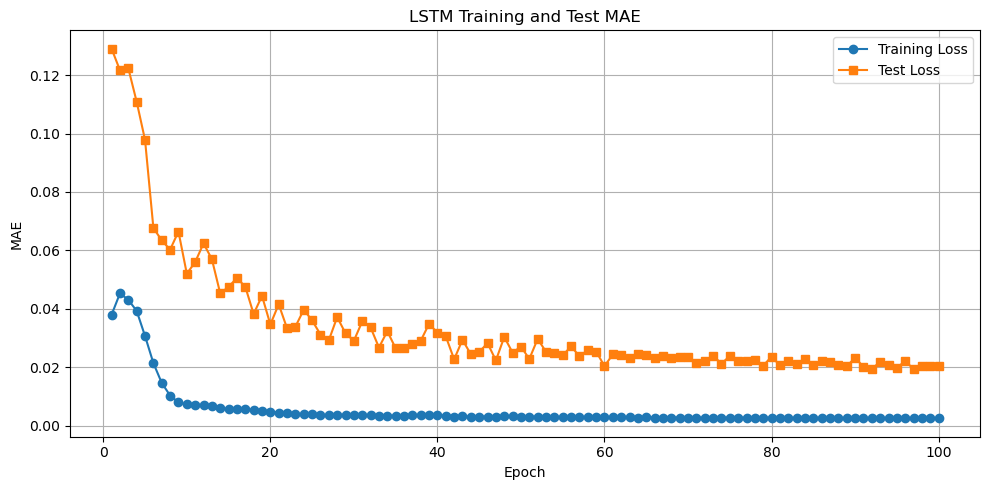

In [44]:
plot_train_test_loss(
    train_losses=train_losses_LSTM,
    test_losses=test_losses_LSTM,
    title="LSTM Training and Test MAE",
    ylabel="MAE"
)

In [45]:
 evaluate_model(
    model=model_LSTM,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 0.0205
MSE: 0.0005
RMSE: 0.0215
MAPE (%): 2.8348
sMAPE (%): 2.7892


In [46]:
next_price = predict_next_price(
    model=model_LSTM,
    data=test_scaled,
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [58107.50219969 58120.31716473 58097.19356285]


In [47]:
class GRUModel(nn.Module):

    def __init__(
        self,
        feature_size=4,
        hidden_size=128,
        num_layers=1,
        horizon=3
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=feature_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):

        output, _ = self.gru(x)

        # Select the last time step
        output = output[:, -1, :]

        output = self.fc(output)

        return output

In [48]:
window_size = 60
feature_size = 4
hidden_size = 128
num_layers = 1
horizon = 3

X_train, y_train = create_sliding_windows(
    train_scaled,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_scaled,
    window_size=window_size,
    horizon=horizon
)

# Select Price as the target
y_train = y_train[:, :, 0]
y_test = y_test[:, :, 0]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [49]:
model_GRU = GRUModel(
    feature_size=feature_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    horizon=horizon
)

In [50]:
print(model_GRU)

GRUModel(
  (gru): GRU(4, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [51]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_GRU.parameters(),
    lr=0.0001
)

In [52]:
train_losses_GRU, test_losses_GRU = train_model(
    model=model_GRU,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 0.0323 Test MAE: 0.1073
Epoch [10/100] Train MAE: 0.0038 Test MAE: 0.0227
Epoch [20/100] Train MAE: 0.0036 Test MAE: 0.0248
Epoch [30/100] Train MAE: 0.0032 Test MAE: 0.0204
Epoch [40/100] Train MAE: 0.0032 Test MAE: 0.0199
Epoch [50/100] Train MAE: 0.0030 Test MAE: 0.0201
Epoch [60/100] Train MAE: 0.0028 Test MAE: 0.0179
Epoch [70/100] Train MAE: 0.0027 Test MAE: 0.0161
Epoch [80/100] Train MAE: 0.0025 Test MAE: 0.0166
Epoch [90/100] Train MAE: 0.0024 Test MAE: 0.0145


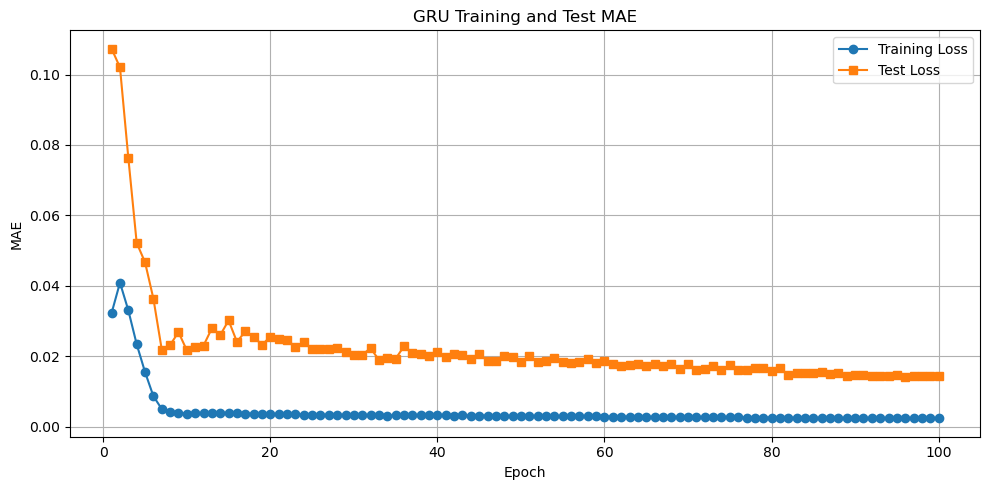

In [53]:
plot_train_test_loss(
    train_losses=train_losses_GRU,
    test_losses=test_losses_GRU,
    title="GRU Training and Test MAE",
    ylabel="MAE"
)

In [54]:
 evaluate_model(
    model=model_GRU,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 0.0144
MSE: 0.0002
RMSE: 0.0154
MAPE (%): 2.0039
sMAPE (%): 1.9796


In [55]:
next_price = predict_next_price(
    model=model_GRU,
    data=test_scaled,
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [57860.61143713 57889.53882333 57905.06280223]


In [56]:
class Conv1DModel(nn.Module):

    def __init__(
        self,
        feature_size=4,
        hidden_size=128,
        horizon=3
    ):
        super().__init__()

        self.conv = nn.Conv1d(
            in_channels=feature_size,
            out_channels=hidden_size,
            kernel_size=3
        )

        self.relu = nn.ReLU()

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):

        # Change:
        # (batch, sequence, features)
        # to
        # (batch, features, sequence)

        x = x.permute(0, 2, 1)

        x = self.conv(x)

        x = self.relu(x)

        x = self.pool(x)

        x = x.squeeze(-1)

        x = self.fc(x)

        return x

In [57]:
window_size = 60
feature_size = 4
hidden_size = 128
num_layers = 1
horizon = 3

X_train, y_train = create_sliding_windows(
    train_scaled,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_scaled,
    window_size=window_size,
    horizon=horizon
)

# Select Price as the target
y_train = y_train[:, :, 0]
y_test = y_test[:, :, 0]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [58]:
model_Conv1D = Conv1DModel(
    feature_size=feature_size,
    hidden_size=hidden_size,
    horizon=horizon
)

In [59]:
print(model_Conv1D)

Conv1DModel(
  (conv): Conv1d(4, 128, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveAvgPool1d(output_size=1)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [60]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_Conv1D.parameters(),
    lr=0.0001
)

In [61]:
train_losses_Conv1D, test_losses_Conv1D = train_model(
    model=model_Conv1D,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 0.0377 Test MAE: 0.0510
Epoch [10/100] Train MAE: 0.0059 Test MAE: 0.0193
Epoch [20/100] Train MAE: 0.0058 Test MAE: 0.0187
Epoch [30/100] Train MAE: 0.0056 Test MAE: 0.0187
Epoch [40/100] Train MAE: 0.0056 Test MAE: 0.0183
Epoch [50/100] Train MAE: 0.0055 Test MAE: 0.0180
Epoch [60/100] Train MAE: 0.0055 Test MAE: 0.0180
Epoch [70/100] Train MAE: 0.0054 Test MAE: 0.0175
Epoch [80/100] Train MAE: 0.0054 Test MAE: 0.0172
Epoch [90/100] Train MAE: 0.0054 Test MAE: 0.0173


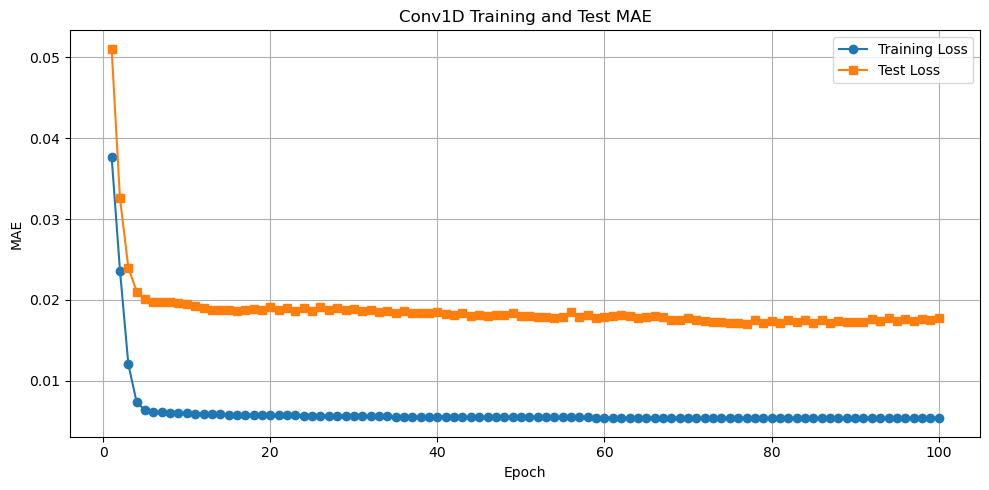

In [62]:
plot_train_test_loss(
    train_losses=train_losses_Conv1D,
    test_losses=test_losses_Conv1D,
    title="Conv1D Training and Test MAE",
    ylabel="MAE"
)

In [63]:
 evaluate_model(
    model=model_Conv1D,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 0.0177
MSE: 0.0004
RMSE: 0.0198
MAPE (%): 2.4665
sMAPE (%): 2.4270


In [64]:
next_price = predict_next_price(
    model=model_Conv1D,
    data=test_scaled,
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [58285.2771483  58325.70313238 58293.76597292]


In [65]:
class NBeatsBlock(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        horizon
    ):
        super().__init__()

        self.fc_stack = nn.Sequential(

            nn.Linear(
                input_size,
                hidden_size
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_size,
                hidden_size
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_size,
                hidden_size
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_size,
                hidden_size
            ),

            nn.ReLU()
        )

        self.backcast = nn.Linear(
            hidden_size,
            input_size
        )

        self.forecast = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):

        output = self.fc_stack(x)

        backcast = self.backcast(output)

        forecast = self.forecast(output)

        return backcast, forecast

In [66]:
class NBeatsModel(nn.Module):

    def __init__(
        self,
        window_size=60,
        feature_size=4,
        hidden_size=128,
        horizon=3,
        num_blocks=3
    ):
        super().__init__()

        input_size = (
            window_size * feature_size
        )

        self.blocks = nn.ModuleList([

            NBeatsBlock(
                input_size=input_size,
                hidden_size=hidden_size,
                horizon=horizon
            )

            for _ in range(num_blocks)
        ])

    def forward(self, x):

        # Flatten time and feature dimensions
        x = x.reshape(
            x.size(0),
            -1
        )

        residual = x

        forecasts = []

        for block in self.blocks:

            backcast, forecast = block(
                residual
            )

            forecasts.append(forecast)

            residual = residual - backcast

        output = torch.stack(
            forecasts,
            dim=0
        ).sum(dim=0)

        return output

In [67]:
window_size = 60
feature_size = 4
hidden_size = 128
num_layers = 1
horizon = 3

X_train, y_train = create_sliding_windows(
    train_scaled,
    window_size=window_size,
    horizon=horizon
)

X_test, y_test = create_sliding_windows(
    test_scaled,
    window_size=window_size,
    horizon=horizon
)

# Select Price as the target
y_train = y_train[:, :, 0]
y_test = y_test[:, :, 0]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_loader, test_loader = create_data_loaders(
    X_train_tensor,
    y_train_tensor,
    X_test_tensor,
    y_test_tensor,
    batch_size=128
)

In [68]:
model_NBEATS = NBeatsModel(
    window_size=window_size,
    feature_size=feature_size,
    hidden_size=hidden_size,
    horizon=horizon,
    num_blocks=5
)

In [69]:
print(model_NBEATS)

NBeatsModel(
  (blocks): ModuleList(
    (0-4): 5 x NBeatsBlock(
      (fc_stack): Sequential(
        (0): Linear(in_features=240, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=128, bias=True)
        (7): ReLU()
      )
      (backcast): Linear(in_features=128, out_features=240, bias=True)
      (forecast): Linear(in_features=128, out_features=3, bias=True)
    )
  )
)


In [70]:
criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model_NBEATS.parameters(),
    lr=0.0001
)

In [75]:
train_losses_NBEATS, test_losses_NBEATS = train_model(
    model=model_NBEATS,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=100
)

Epoch [0/100] Train MAE: 0.0042 Test MAE: 0.0258
Epoch [10/100] Train MAE: 0.0037 Test MAE: 0.0225
Epoch [20/100] Train MAE: 0.0034 Test MAE: 0.0201
Epoch [30/100] Train MAE: 0.0032 Test MAE: 0.0194
Epoch [40/100] Train MAE: 0.0031 Test MAE: 0.0186
Epoch [50/100] Train MAE: 0.0030 Test MAE: 0.0172
Epoch [60/100] Train MAE: 0.0028 Test MAE: 0.0173
Epoch [70/100] Train MAE: 0.0028 Test MAE: 0.0161
Epoch [80/100] Train MAE: 0.0027 Test MAE: 0.0146
Epoch [90/100] Train MAE: 0.0025 Test MAE: 0.0141


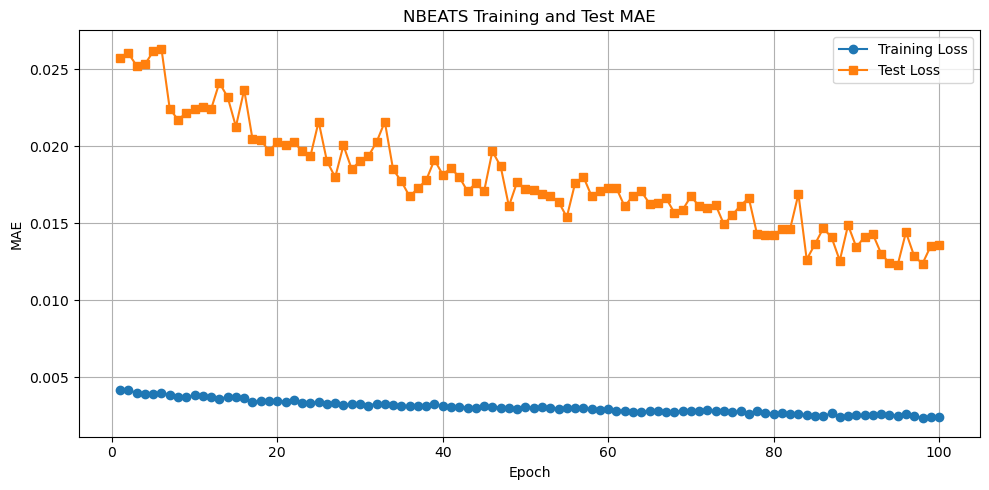

In [77]:
plot_train_test_loss(
    train_losses=train_losses_NBEATS,
    test_losses=test_losses_NBEATS,
    title="NBEATS Training and Test MAE",
    ylabel="MAE"
)

In [78]:
 evaluate_model(
    model=model_NBEATS,
    test_loader=test_loader
)


Model Evaluation Results
------------------------------
MAE: 0.0136
MSE: 0.0002
RMSE: 0.0147
MAPE (%): 1.8929
sMAPE (%): 1.8708


In [79]:
next_price = predict_next_price(
    model=model_NBEATS,
    data=test_scaled,
    window_size=window_size
)
print("Next Price is:", next_price.squeeze())

Next Price is: [57910.14955876 57931.29643048 57944.61484057]
